In [164]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

# AI Inventory Intelligence

### Explainable Demand Forecasting and Inventory Optimization

**Objective:**  
Develop a data-driven inventory decision-support system that forecasts future product demand and converts those forecasts into actionable inventory recommendations.

### Business Problem

Retailers need to balance two competing risks:

- Stockouts → lost sales and customer dissatisfaction
- Overstock → unnecessary inventory holding costs

### Proposed Solution

Historical sales + price + calendar information
→ Demand Forecasting
→ Inventory Risk Analysis
→ Reorder Recommendation
→ Scenario Simulation

In [165]:
df_calendar = pd.read_csv('/kaggle/input/datasets/vinayakmishra333/m5forecastin/calendar.csv')
df_sales = pd.read_csv('/kaggle/input/datasets/vinayakmishra333/m5forecastin/sales_train_validation.csv')
df_prices = pd.read_csv('/kaggle/input/datasets/vinayakmishra333/m5forecastin/sell_prices.csv')

## 1. Data Understanding

In [166]:
print("Calendar:", df_calendar.shape)
print("Sales:", df_sales.shape)
print("Prices:", df_prices.shape)

Calendar: (1969, 14)
Sales: (30490, 1919)
Prices: (6841121, 4)


(Numb of rows, numb of cols)
--> Calendar: (1969, 14) means 1969 calendar days, 14 pieces of information about each day
--> Sales: (30490, 1919) means 30490 product-store combinations and 1919 information about those products/stores + daily sales

In [167]:
df_calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [168]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [169]:
df_calendar.columns.tolist()

['date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'd',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI']

In [170]:
df_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,...,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,1,2,1,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0,0,2,2,0,0,1,4,0,0,0,0,1,1,2,0,4,0,1,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,1,1,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,0,0,0,0,2,0,1,0,0,1,1,1,0,2,3,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,2,3,0,2,0,0,2,2,0,0,2,1,2,1,1,1,2,...,3,2,4,3,1,2,3,0,8,2,1,2,2,5,2,6,1,0,3,5,1,1,6,4,3,2,2,3,2,1,0,0,0,2,0,5,4,2,1,1,2,3,0,6,0,0,0,1,0,1,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,3,0,0,1,1,0,3,1,0,4,1,2,0,0,0,1,1,2,0,0,5,2,2,2,1,0,0,0,3,0,0,0,3,1,1,1,1,2,1,0,0,1,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [171]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [172]:
df_sales.columns.tolist()

['id',
 'item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'd_1',
 'd_2',
 'd_3',
 'd_4',
 'd_5',
 'd_6',
 'd_7',
 'd_8',
 'd_9',
 'd_10',
 'd_11',
 'd_12',
 'd_13',
 'd_14',
 'd_15',
 'd_16',
 'd_17',
 'd_18',
 'd_19',
 'd_20',
 'd_21',
 'd_22',
 'd_23',
 'd_24',
 'd_25',
 'd_26',
 'd_27',
 'd_28',
 'd_29',
 'd_30',
 'd_31',
 'd_32',
 'd_33',
 'd_34',
 'd_35',
 'd_36',
 'd_37',
 'd_38',
 'd_39',
 'd_40',
 'd_41',
 'd_42',
 'd_43',
 'd_44',
 'd_45',
 'd_46',
 'd_47',
 'd_48',
 'd_49',
 'd_50',
 'd_51',
 'd_52',
 'd_53',
 'd_54',
 'd_55',
 'd_56',
 'd_57',
 'd_58',
 'd_59',
 'd_60',
 'd_61',
 'd_62',
 'd_63',
 'd_64',
 'd_65',
 'd_66',
 'd_67',
 'd_68',
 'd_69',
 'd_70',
 'd_71',
 'd_72',
 'd_73',
 'd_74',
 'd_75',
 'd_76',
 'd_77',
 'd_78',
 'd_79',
 'd_80',
 'd_81',
 'd_82',
 'd_83',
 'd_84',
 'd_85',
 'd_86',
 'd_87',
 'd_88',
 'd_89',
 'd_90',
 'd_91',
 'd_92',
 'd_93',
 'd_94',
 'd_95',
 'd_96',
 'd_97',
 'd_98',
 'd_99',
 'd_100',
 'd_101',
 'd_102',
 'd_103',
 'd_104',


In [173]:
df_sales["store_id"].value_counts()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

In [174]:
df_sales["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [175]:
df_sales["dept_id"].value_counts()

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

`FOODS_3` has 8,230 product-store combinations across all 10 stores.
To find the actual number of unique products, use `nunique()` on `item_id`.

In [176]:
df_sales.groupby("dept_id")["item_id"].nunique()

dept_id
FOODS_1        216
FOODS_2        398
FOODS_3        823
HOBBIES_1      416
HOBBIES_2      149
HOUSEHOLD_1    532
HOUSEHOLD_2    515
Name: item_id, dtype: int64

In [177]:
df_sales.groupby("cat_id")["item_id"].nunique()

cat_id
FOODS        1437
HOBBIES       565
HOUSEHOLD    1047
Name: item_id, dtype: int64

In [178]:
df_sales["state_id"].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [179]:
# Check for full-row duplicates
print(
    "Duplicate calendar days:",
    df_calendar.duplicated(subset=["d"]).sum()
)

print(
    "Duplicate sales IDs:",
    df_sales.duplicated(subset=["id"]).sum()
)

print(
    "Duplicate price records:",
    df_prices.duplicated(
        subset=["store_id", "item_id", "wm_yr_wk"]
    ).sum()
)

Duplicate calendar days: 0
Duplicate sales IDs: 0
Duplicate price records: 0


In [180]:
df_sales[["item_id", "dept_id", "cat_id"]].drop_duplicates().head(20)

,item_id,dept_id,cat_id
0,HOBBIES_1_001,HOBBIES_1,HOBBIES
1,HOBBIES_1_002,HOBBIES_1,HOBBIES
2,HOBBIES_1_003,HOBBIES_1,HOBBIES
3,HOBBIES_1_004,HOBBIES_1,HOBBIES
4,HOBBIES_1_005,HOBBIES_1,HOBBIES
5,HOBBIES_1_006,HOBBIES_1,HOBBIES
6,HOBBIES_1_007,HOBBIES_1,HOBBIES
7,HOBBIES_1_008,HOBBIES_1,HOBBIES
8,HOBBIES_1_009,HOBBIES_1,HOBBIES
9,HOBBIES_1_010,HOBBIES_1,HOBBIES


In [181]:
selected_stores = ["CA_1", "TX_1", "WI_1"]

sales_subset = df_sales[
    (df_sales["store_id"].isin(selected_stores)) &
    (df_sales["cat_id"] == "FOODS")
].copy()

print(sales_subset.shape)

(4311, 1919)


In [182]:
print("Product-store combinations:", len(sales_subset))
print("Unique products:", sales_subset["item_id"].nunique())
print("Unique stores:", sales_subset["store_id"].nunique())
print(
    "Unique product-store pairs:",
    sales_subset[
        ["item_id", "store_id"]
    ].drop_duplicates().shape[0]
)

Product-store combinations: 4311
Unique products: 1437
Unique stores: 3
Unique product-store pairs: 4311


Note that these are all within the sales_subset where the selected stores are only `CA_1`, `TX_1`, and `WI_1` AND only the `FOOD` category

In [183]:
# Quick Data Inspection
example = sales_subset.iloc[0]

print("Product:", example["item_id"])
print("Store:", example["store_id"])

Product: FOODS_1_001
Store: CA_1


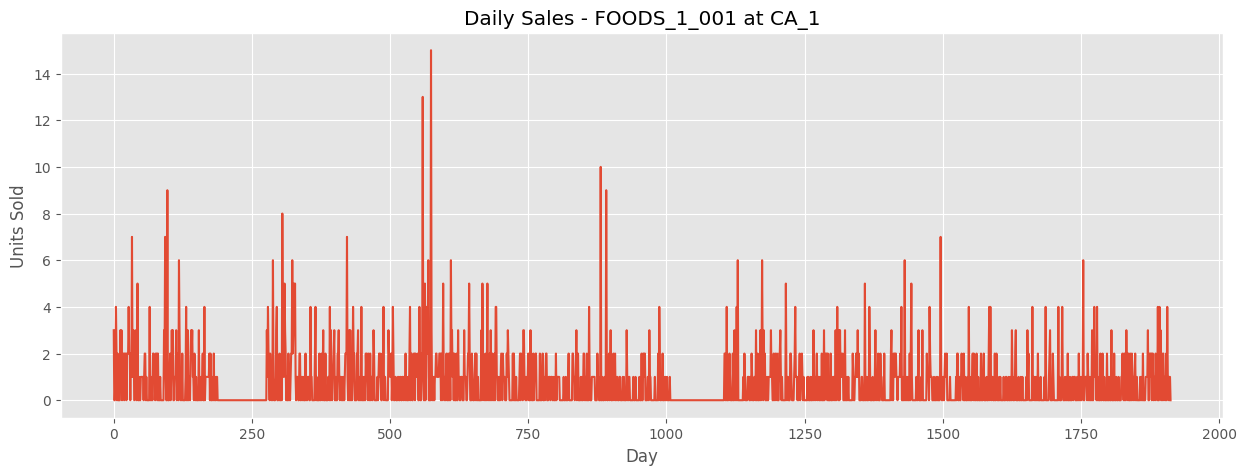

In [184]:
day_columns = [col for col in df_sales.columns if col.startswith("d_")]

example_sales = example[day_columns].values

plt.figure(figsize=(15, 5))
plt.plot(example_sales)
plt.title(f"Daily Sales - {example['item_id']} at {example['store_id']}")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.show()

## 2. Data Cleaning and Pre-processing

In [185]:
id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

day_columns = [
    col for col in sales_subset.columns 
    if col.startswith("d_")
]

sales_long = sales_subset.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="sales"
)

sales_long.head(20)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3
5,FOODS_1_006_CA_1_validation,FOODS_1_006,FOODS_1,FOODS,CA_1,CA,d_1,0
6,FOODS_1_008_CA_1_validation,FOODS_1_008,FOODS_1,FOODS,CA_1,CA,d_1,0
7,FOODS_1_009_CA_1_validation,FOODS_1_009,FOODS_1,FOODS,CA_1,CA,d_1,0
8,FOODS_1_010_CA_1_validation,FOODS_1_010,FOODS_1,FOODS,CA_1,CA,d_1,0
9,FOODS_1_011_CA_1_validation,FOODS_1_011,FOODS_1,FOODS,CA_1,CA,d_1,2


In [186]:
# Validation after melt
expected_rows = len(sales_subset) * len(day_columns)

print("Expected rows: ", expected_rows)
print("Actual rows: ", len(sales_long))

assert len(sales_long) == expected_rows

Expected rows:  8246943
Actual rows:  8246943


In [187]:
# Retain some more columns
calendar_columns = [
    "d",
    "date",
    "wm_yr_wk",
    "weekday",
    "wday",
    "month",
    "year",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

sales_long = sales_long.merge(
    df_calendar[calendar_columns],
    on="d",
    how="left",
    validate="many_to_one"
)

#### What's validate="many_to_one"?

Many sales records can belong to the same calendar day, but every d should match exactly one calendar row.

In [188]:
sales_long.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')

In [189]:
sales_long["date"] = pd.to_datetime(sales_long["date"])

In [190]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [191]:
sales_long = sales_long.merge(
    df_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
    validate="many_to_one"
)

In [192]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.00
1,FOODS_1_002_CA_1_validation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.88
2,FOODS_1_003_CA_1_validation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.88
3,FOODS_1_004_CA_1_validation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,FOODS_1_005_CA_1_validation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.94


### Missing Prices

In [193]:
print(sales_long["sell_price"].isna().sum())
print(sales_long["sell_price"].isna().mean())

1789536
0.2169938606341768


Missing prices = 1,789,536 \
Percentage ≈ 21.7%

In [194]:
# Make new column to denote whether the price is 
# available for that product or not
sales_long["price_available"] = (
    sales_long["sell_price"].notna()
).astype("int8")

Why?

Because: sell_price = NaN

may itself tell us that a product did not have a recorded selling price during that week.

We don't want to invent a price.

### Add dashboard-friendly columns

In [195]:
# Weekend
sales_long["is_weekend"] = (
    sales_long["weekday"]
    .isin(["Saturday", "Sunday"])
).astype("int8")

In [196]:
# Event Day
sales_long["is_event"] = (
    sales_long["event_name_1"].notna()
    | sales_long["event_name_2"].notna()
).astype("int8")

In [197]:
# SNAP (subsidi pemerintah)
# right now we have snap_CA, snap_TX, and snap_WI, but
# each sales row belongs to only one state, so modify
sales_long["snap"] = np.select(
    [
        sales_long["state_id"] == "CA",
        sales_long["state_id"] == "TX",
        sales_long["state_id"] == "WI",
    ],
    [
        sales_long["snap_CA"],
        sales_long["snap_TX"],
        sales_long["snap_WI"],
    ],
    default=0
).astype("int8")

This creates a single unified snap column by picking the right state-specific SNAP column based on state_id. SNAP = Supplemental Nutrition Assistance Program (food stamps) — in the M5 dataset, each state has its own snap indicator per day.

**The conditions**
``` python
sales_long["state_id"] == "CA"   # True where state is CA
sales_long["state_id"] == "TX"
sales_long["state_id"] == "WI"
```
**The choices**
```python
sales_long["snap_CA"]   # the entire CA snap column
sales_long["snap_TX"]
sales_long["snap_WI"]
```

So now every row simply has snap = 0 or snap = 1

In [198]:
# missing event values
print(sales_long["event_name_1"].isna().sum())
print(sales_long["event_name_2"].isna().sum())

7583049
8229699


In [199]:
# for display purposes, create new column:
sales_long["event_name_1_display"] = (
    sales_long["event_name_1"]
    .fillna("No event")
)

### Duplicate check again

In [200]:
duplicate_count = sales_long.duplicated(
    subset=[
        "item_id",
        "store_id",
        "date"
    ]
).sum()

print("Duplicate product-store-date rows: ", duplicate_count)

Duplicate product-store-date rows:  0


#### Why these three columns?

Because one row should mean:

```
Sales of one particular product, at one particular store, on one particular date.
```
For example:

```
item	store	date	sales
FOODS_1_001	CA_1	2011-01-29	3
```
There should never be another row with the exact same product/store/date.

In [201]:
print("=== FINAL DATA VALIDATION ===")

print("\nShape:")
print(sales_long.shape)

print("\nDate range:")
print(
    sales_long["date"].min(),
    "to",
    sales_long["date"].max()
)

print("\nUnique entities:")
print(
    "Products:",
    sales_long["item_id"].nunique()
)
print(
    "Stores:",
    sales_long["store_id"].nunique()
)
print(
    "Departments:",
    sales_long["dept_id"].nunique()
)

print("\nData quality:")
print(
    "Duplicate product-store-date:",
    sales_long.duplicated(
        ["item_id", "store_id", "date"]
    ).sum()
)

print(
    "Missing sales:",
    sales_long["sales"].isna().sum()
)

print(
    "Missing dates:",
    sales_long["date"].isna().sum()
)

print(
    "Missing price:",
    sales_long["sell_price"].isna().sum()
)

print(
    "Missing price %:",
    f"{sales_long['sell_price'].isna().mean():.2%}"
)

=== FINAL DATA VALIDATION ===

Shape:
(8246943, 27)

Date range:
2011-01-29 00:00:00 to 2016-04-24 00:00:00

Unique entities:
Products: 1437
Stores: 3
Departments: 3

Data quality:
Duplicate product-store-date: 0
Missing sales: 0
Missing dates: 0
Missing price: 1789536
Missing price %: 21.70%


## 3. Export

In [202]:
sales_long = (
    sales_long
    .sort_values(
        ["store_id", "item_id", "date"]
    )
    .reset_index(drop=True)
)

In [203]:
sales_long.to_parquet(
    "/kaggle/working/m5_dashboard_clean.parquet",
    index=False
)

Why Parquet? \
Because you have 8.2 million rows. CSV will be huge and slow for Streamlit.

## 4. Visualization?

In [204]:
sales_long["sales"].describe()

count    8.246943e+06
mean     1.527522e+00
std      4.399196e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      6.480000e+02
Name: sales, dtype: float64

| Statistic | Meaning |
|---|---|
| **count** | Number of observations |
| **mean** | Average units sold per product-store-day |
| **std** | How much sales fluctuate |
| **min** | Lowest sales |
| **25%** | 25th percentile |
| **50%** | Median |
| **75%** | 75th percentile |
| **max** | Highest daily sales |

### Department Sales

In [205]:
department_sales = (
    sales_long
    .groupby("dept_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

department_sales

dept_id
FOODS_3    9039731
FOODS_2    2117451
FOODS_1    1440207
Name: sales, dtype: int64

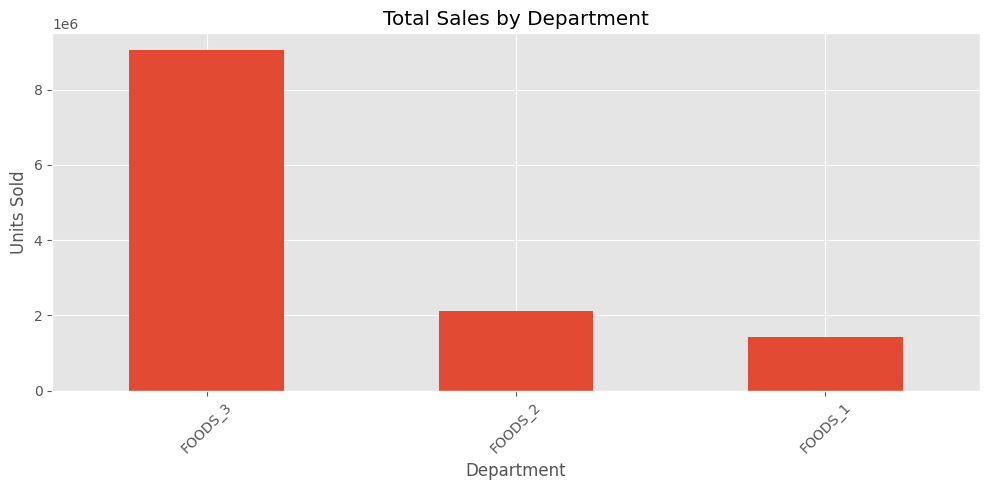

In [206]:
plt.figure(figsize=(10, 5))

department_sales.plot(kind="bar")

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Store Sales

In [207]:
store_sales = (
    sales_long
    .groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
CA_1    5380828
TX_1    3778209
WI_1    3438352
Name: sales, dtype: int64

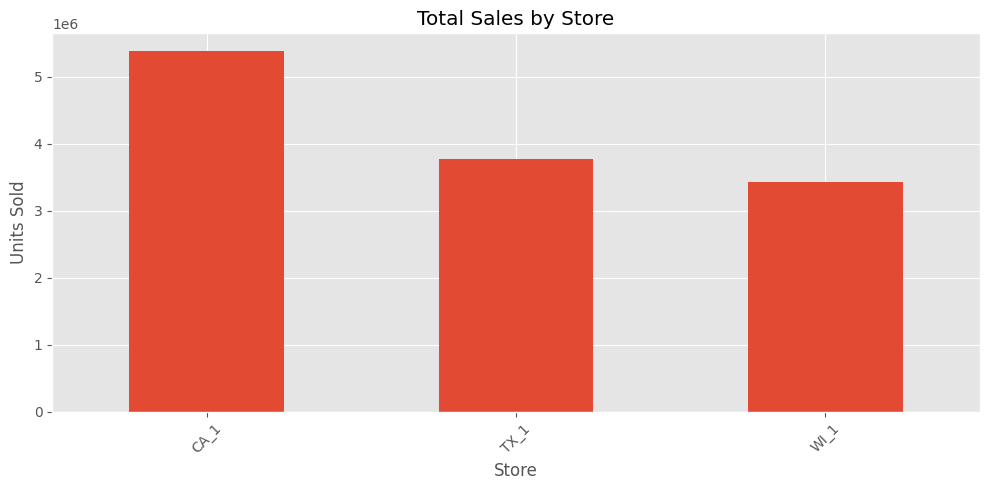

In [208]:
plt.figure(figsize=(10, 5))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Sales

In [209]:
daily_sales = (
    sales_long
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2011-01-29,6601
1,2011-01-30,6367
2,2011-01-31,4362
3,2011-02-01,4836
4,2011-02-02,3363


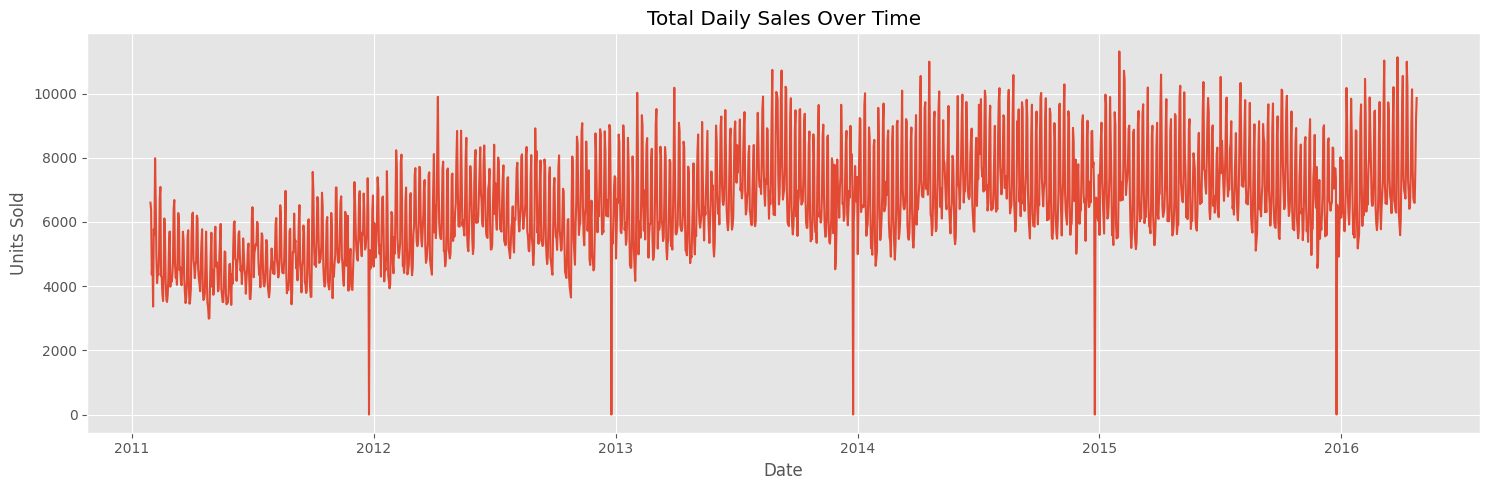

In [210]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

### Weekday Sales

In [211]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    sales_long
    .groupby("weekday")["sales"]
    .mean()
    .reindex(weekday_order)
)

weekday_sales

weekday
Monday       1.430969
Tuesday      1.310897
Wednesday    1.302519
Thursday     1.314054
Friday       1.527363
Saturday     1.898692
Sunday       1.905418
Name: sales, dtype: float64

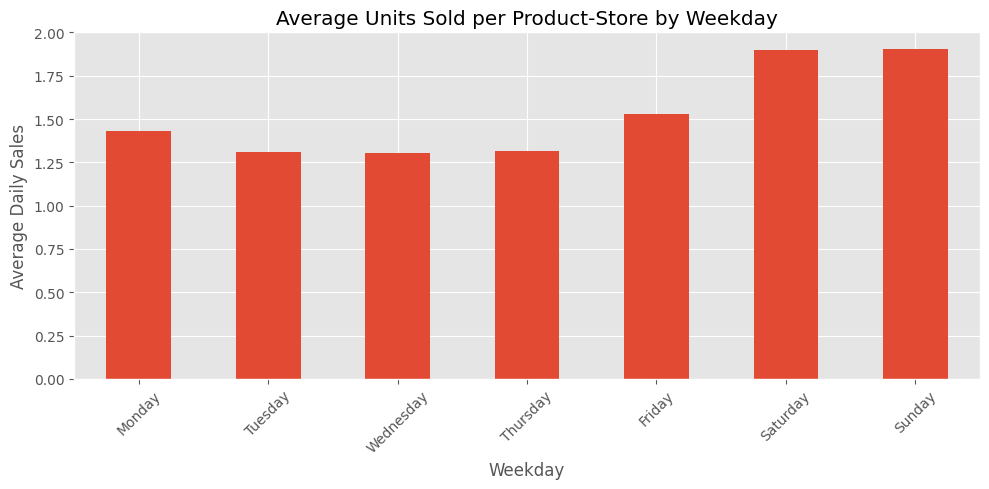

In [212]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Units Sold per Product-Store by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Daily Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales

In [213]:
monthly_sales = (
    sales_long
    .groupby("month")["sales"]
    .mean()
)

monthly_sales

month
1     1.519475
2     1.501973
3     1.505334
4     1.531585
5     1.490109
6     1.569531
7     1.564506
8     1.590208
9     1.545377
10    1.504691
11    1.491009
12    1.523791
Name: sales, dtype: float64

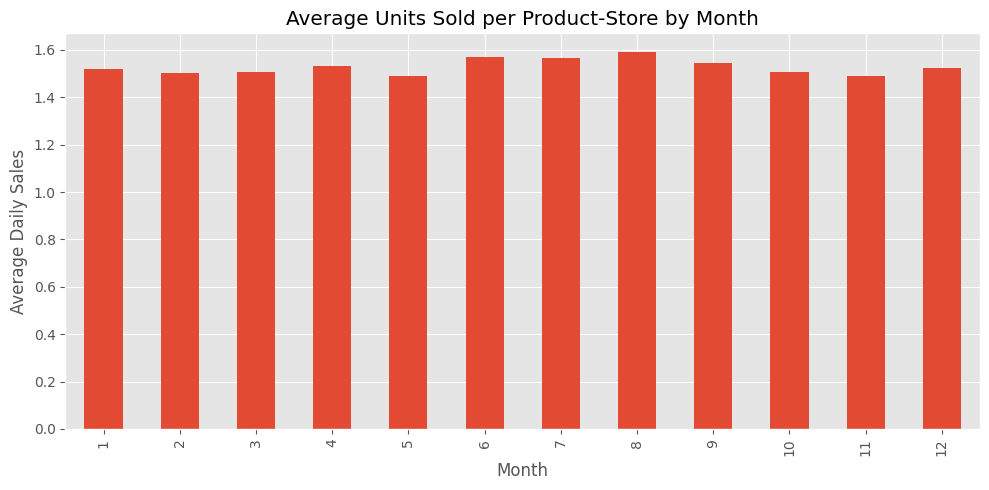

In [214]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Units Sold per Product-Store by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.tight_layout()
plt.show()

### Top Products

In [215]:
# Top-selling product-store combinations
top_series = (
    sales_long
    .groupby(["item_id", "store_id"])["sales"]
    .sum()
    .sort_values(ascending=False)
)

top_series.head(10)

item_id      store_id
FOODS_3_090  CA_1        127203
FOODS_3_586  TX_1        112454
FOODS_3_090  TX_1         93684
FOODS_3_586  CA_1         87691
FOODS_3_226  WI_1         78993
FOODS_3_252  CA_1         74971
FOODS_3_555  TX_1         69516
FOODS_3_120  CA_1         61899
FOODS_3_252  TX_1         56294
FOODS_3_714  CA_1         54080
Name: sales, dtype: int64

In [216]:
example_series = sales_long[
    (sales_long["item_id"] == example_item) &
    (sales_long["store_id"] == example_store)
].copy()

example_series = example_series.sort_values("date")

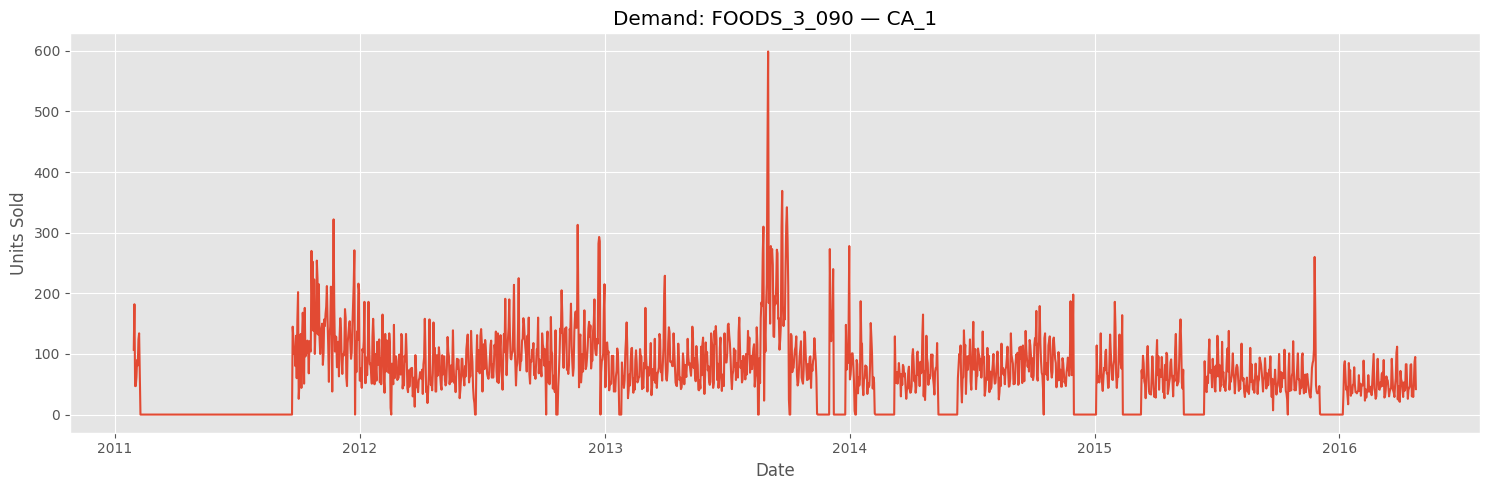

In [217]:
plt.figure(figsize=(15, 5))

plt.plot(
    example_series["date"],
    example_series["sales"]
)

plt.title(
    f"Demand: {example_item} — {example_store}"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

### Event vs Normal days

In [218]:
event_sales = (
    sales_long
    .groupby("is_event")["sales"]
    .mean()
)

event_sales

is_event
0    1.532550
1    1.470098
Name: sales, dtype: float64

`0` = no event that day → average sales were about 1.53 units \
`1` = there was an event → average sales were about 1.47 units

So, surprisingly, the raw average is about 4.1% lower on event days.

### SNAP vs non-SNAP

In [219]:
snap_sales = (
    sales_long
    .groupby("snap")["sales"]
    .mean()
)

snap_sales

snap
0    1.468361
1    1.648004
Name: sales, dtype: float64

`0` = non-SNAP day → average sales were about 1.47 units \
`1` = SNAP day → average sales were about 1.65 units

So SNAP days have about 12.2% higher average sales.

### Look into correlations

In [220]:
corr_cols = [
    "sales",
    "is_weekend",
    "is_event",
    "snap",
    "price_available"
]

sales_long[corr_cols].corr()

,sales,is_weekend,is_event,snap,price_available
sales,1.000000,0.053944,-0.003862,0.019191,0.182791
is_weekend,0.053944,1.000000,0.012261,0.001303,0.000870
is_event,-0.003862,0.012261,1.000000,0.007974,-0.002214
snap,0.019191,0.001303,0.007974,1.000000,-0.002579
price_available,0.182791,0.000870,-0.002214,-0.002579,1.000000


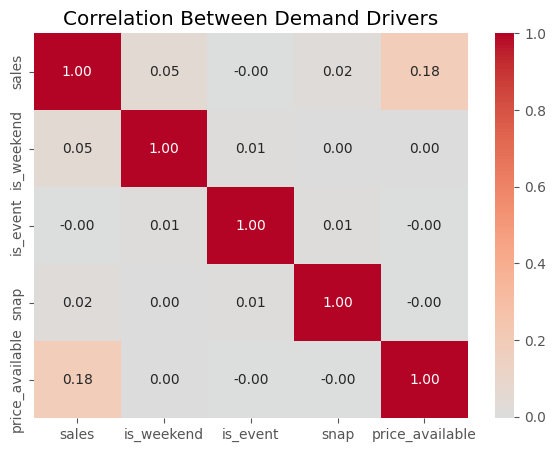

In [221]:
corr = sales_long[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Demand Drivers")
plt.show()

#### Very weak correlations among all of them

### Look into groupby-mean comparison

In [222]:
def binary_effect(df, column):
    means = df.groupby(column)["sales"].mean()

    return pd.Series({
        "avg_0": means.loc[0],
        "avg_1": means.loc[1],
        "uplift_pct":
            (means.loc[1] / means.loc[0] - 1) * 100
    })

for col in ["is_weekend", "is_event", "snap"]:
    print(col)
    print(binary_effect(sales_long, col))
    print()

is_weekend
avg_0          1.377161
avg_1          1.902055
uplift_pct    38.114221
dtype: float64

is_event
avg_0         1.532550
avg_1         1.470098
uplift_pct   -4.075048
dtype: float64

snap
avg_0          1.468361
avg_1          1.648004
uplift_pct    12.234249
dtype: float64



```python
is_weekend
avg_0          1.377161
avg_1          1.902055
uplift_pct    38.114221
```

Interpretation: Items sell **38% more on weekends than weekdays, on average**. This is a strong, meaningful effect — weekends matter a lot.

Interesting: the correlation matrix said sales ↔ is_weekend = 0.054 (weak), yet the uplift here is +38%. Why the discrepancy? Because correlation measures linear strength across all rows, while a groupby-mean comparison captures the mean shift directly. Weekend days are only ~2/7 of rows, so they don't move the overall correlation much — but when they are weekends, sales jump hard. This is exactly why you plot instead of trusting correlation alone.

```python
is_event
avg_0         1.532550
avg_1         1.470098
uplift_pct   -4.075048
```

Interpretation: On event days, sales are **4% lower than non-event days**. Two possibilities:

1. Events genuinely suppress sales (unlikely for retail — events usually boost foot traffic).

2. Confounding — event days may be disproportionately weekdays, or in states/stores with lower baseline sales. The correlation matrix showed is_weekend ↔ is_event = 0.012, so that's not it directly, but store/state mix could still be at play.

In [223]:
# slice by state
pivot = sales_long.groupby(["state_id","is_event"])["sales"].mean().unstack()
pivot["uplift_pct"] = (pivot[1] / pivot[0] - 1) * 100
pivot

is_event,0,1,uplift_pct
state_id,,,
CA,1.965825,1.861043,-5.330212
TX,1.372259,1.398897,1.941136
WI,1.259565,1.150354,-8.670546


The values (1.15 – 1.97) tell you the average units sold per item-store-day in that group.

In [224]:
means = sales_long.groupby(["state_id","is_event","is_weekend"])["sales"].mean().unstack("is_weekend")

# weekend uplift % (per state × event)
weekend_uplift = (means[1] / means[0] - 1) * 100

# event uplift % (per state × weekend)
event_uplift = sales_long.groupby(["state_id","is_weekend","is_event"])["sales"].mean().unstack("is_event")
event_uplift = (event_uplift[1] / event_uplift[0] - 1) * 100

print("=== WEEKEND UPLIFT (%) ===")
print(weekend_uplift.round(1))
print()
print("=== EVENT UPLIFT (%) ===")
print(event_uplift.round(1))

=== WEEKEND UPLIFT (%) ===
state_id  is_event
CA        0           43.0
          1           35.4
TX        0           30.9
          1           35.6
WI        0           40.3
          1           27.8
dtype: float64

=== EVENT UPLIFT (%) ===
state_id  is_weekend
CA        0             -4.1
          1             -9.2
TX        0              0.0
          1              3.6
WI        0             -6.2
          1            -14.5
dtype: float64


Weekend days drive a large and universal sales lift of roughly +28% to +43% across every state and event condition, making day-of-week the strongest and most consistent pattern in the data. 

The effect of events is weaker and state-dependent: events reduce sales in CA (by about 4–9%) and WI (by about 6–15%), have essentially no effect in TX, and the negative impact tends to be worse on weekends than weekdays. These event effects survive controlling for weekend, so they aren't just a weekday/weekend confounding artifact — though the numbers are still correlational, based on means of zero-inflated item-store-day sales, and worth verifying with sample sizes, significance tests, and a check of what is_event actually encodes before treating them as causal.

```python
snap
avg_0          1.468361
avg_1          1.648004
uplift_pct    12.234249
```

Interpretation: On SNAP benefit days, sales are **12% higher**. Makes sense — people have food benefits loaded and spend more. A moderate, believable effect.